<a href="https://colab.research.google.com/github/Kartikiscalm/IML-LAB-/blob/labs/Lab4_Data_Preprocessing_Normalization_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 | Data Preprocessing, Normalization & Multi-Class Classification

We will work through a complete machine-learning workflow:

**raw data → inspection → cleaning → encoding → train/test split → scaling → model training → probabilities → prediction → evaluation**



## Learning Objectives

By the end of this lab, you should be able to:

1. Identify missing, inconsistent, duplicated, invalid, and unusual observations.
2. Choose appropriate strategies for handling missing values.
3. Clean categorical data and perform one-hot encoding.
4. Explain why numerical features may need to be scaled.
5. Perform **Min-Max normalization** and **Z-score standardization**.
6. Distinguish feature scaling from unit-vector normalization.
7. Explain why scaling can matter for some algorithms more than others.
8. Detect and avoid preprocessing **data leakage**.
9. Explain multiclass classification using logits and **softmax**.
10. Relate one-hot labels and likelihood to **categorical cross-entropy**.
11. Train and evaluate a multiclass logistic regression model.
12. Interpret predicted probabilities and a multiclass confusion matrix.


---
# Part A: Data Preprocessing


## 1. Setup

We will use NumPy and Pandas for data manipulation, Matplotlib for simple visualization, and selected scikit-learn utilities for preprocessing and classification.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
from sklearn.datasets import load_wine

pd.set_option("display.max_columns", None)
np.random.seed(42)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. What Is Data Preprocessing?

Data preprocessing means converting raw observations into a clean, consistent, model-ready representation.

Typical preprocessing decisions include:

| Problem | Example | Possible response |
|---|---|---|
| Missing value | unknown delivery time | remove, impute, or investigate |
| Inconsistent category | `Mumbai`, `mumbai`, ` Mumbai ` | standardize the representation |
| Invalid value | quantity = −2 | correct, remove, or mark as missing |
| Duplicate record | same order appears twice | remove if accidental |
| Outlier | unusually large order quantity | investigate before removing |
| Categorical feature | payment method | encode numerically |
| Different scales | revenue vs. rating | scale when appropriate |



## 3. A Raw Dataset: Retail Orders

The following dataset represents a small order log.

Before changing anything, inspect the table and identify what might need attention.


In [ ]:
raw_orders = pd.DataFrame({
    "Order_ID": ["R101", "R102", "R103", "R104", "R105", "R105", "R106", "R107"],
    "Units": [3, 5, np.nan, 4, 2, 2, 120, 6],
    "Customer_Age": [24, 31, 29, -4, 46, 46, 37, 28],
    "Payment_Method": ["Card", "card", "UPI", "Cash", "UPI", "UPI", "cash ", "Card"],
    "Delivery_Days": [2, 3, 5, 4, 2, 2, 1, 30],
    "Returned": ["No", "No", "Yes", "No", "Yes", "Yes", "No", "No"]
})

raw_orders


,Order_ID,Units,Customer_Age,Payment_Method,Delivery_Days,Returned
0,R101,3.0,24,Card,2,No
1,R102,5.0,31,card,3,No
2,R103,NaN,29,UPI,5,Yes
3,R104,4.0,-4,Cash,4,No
4,R105,2.0,46,UPI,2,Yes
5,R105,2.0,46,UPI,2,Yes
6,R106,120.0,37,cash,1,No
7,R107,6.0,28,Card,30,No


### Exercise 1: Diagnose Before You Clean

Without changing `raw_orders`, answer the following:

1. Which column contains missing information?
2. Which value is clearly impossible from the feature's meaning?
3. Which category values appear to be different spellings of the same category?
4. Which order looks duplicated?
5. Which observation could be an outlier?
6. Is an outlier automatically an error?
7. Why should we inspect the data before deleting anything?

Write your answers in a Markdown cell below.


## 4. Missing Values

A missing value means that the information is unavailable. It is not equivalent to a genuine zero.

For example:
- `Units = 0` would mean that zero units were recorded.
- `Units = NaN` means the number of units is unknown.

For numerical data, simple choices include **mean** and **median**. For categorical data, common choices include the **most frequent category** or an explicit `"Unknown"` category.


In [ ]:
print("Missing values per column:")
print(raw_orders.isna().sum())

print("Rows containing a missing value:")
print(raw_orders[raw_orders.isna().any(axis=1)])


Missing values per column:
Order_ID          0
Units             1
Customer_Age      0
Payment_Method    0
Delivery_Days     0
Returned          0
dtype: int64
Rows containing a missing value:
  Order_ID  Units  Customer_Age Payment_Method  Delivery_Days Returned
2     R103    NaN            29            UPI              5      Yes


### Mean vs. Median

Consider the delivery-time measurements:

`[12, 13, 14, 15, 85]`

The value `85` is much larger than the others. It pulls the mean upward, whereas the median remains near the center of the typical observations.



In [ ]:
delivery_times = np.array([12, 13, 14, 15, 85])

print("Values:", delivery_times)
print("Mean:", delivery_times.mean())
print("Median:", np.median(delivery_times))


Values: [12 13 14 15 85]
Mean: 27.8
Median: 14.0


### Exercise 2: Numerical Imputation

Complete the code below.

- Compute the median of `Units`.
- Make a copy of the raw dataset.
- Replace the missing `Units` value with the median.
- Verify that no missing values remain in `Units`.
- Do **not** modify `raw_orders`.


In [ ]:
# ===================== EXERCISE 2 =====================
orders_imputed = raw_orders.copy()

# TODO 1: compute the median number of units
median_units = ...

# TODO 2: fill the missing Units value
# orders_imputed["Units"] = orders_imputed["Units"].fillna(...)

# TODO 3: verify the result
print(orders_imputed)
print("\nRemaining missing Units:", orders_imputed["Units"].isna().sum())


  Order_ID  Units  Customer_Age Payment_Method  Delivery_Days Returned
0     R101    3.0            24           Card              2       No
1     R102    5.0            31           card              3       No
2     R103    NaN            29            UPI              5      Yes
3     R104    4.0            -4           Cash              4       No
4     R105    2.0            46            UPI              2      Yes
5     R105    2.0            46            UPI              2      Yes
6     R106  120.0            37          cash               1       No
7     R107    6.0            28           Card             30       No

Remaining missing Units: 1


## 5. Duplicate Records

A duplicate may cause one observation to be counted more than once.

However, repeated values are not automatically duplicates. In time-series or repeated-measurement data, identical-looking rows can be legitimate.

A safe approach is:

**inspect → understand the collection process → remove only accidental duplicates**


In [ ]:
duplicate_mask = raw_orders.duplicated(keep=False)

print("Rows involved in exact duplicates:")
print(raw_orders[duplicate_mask])


Rows involved in exact duplicates:
  Order_ID  Units  Customer_Age Payment_Method  Delivery_Days Returned
4     R105    2.0            46            UPI              2      Yes
5     R105    2.0            46            UPI              2      Yes


## 6. Inconsistent Categorical Values

Computers treat different strings as different categories.

For example:

`Card`, `card`, and ` Card `

should not become three separate payment methods if they all represent the same thing.

Before encoding a categorical feature, clean:
- whitespace,
- capitalization,
- spelling,
- known aliases or inconsistent naming.

Only after category cleaning should we encode the values.


In [ ]:
print("Raw payment categories:")
print(sorted(raw_orders["Payment_Method"].dropna().unique()))

clean_payment_preview = (
    raw_orders["Payment_Method"]
    .astype(str)
    .str.strip()
    .str.title()
)

print("\nAfter simple text cleaning:")
print(sorted(clean_payment_preview.unique()))


Raw payment categories:
['Card', 'Cash', 'UPI', 'card', 'cash ']

After simple text cleaning:
['Card', 'Cash', 'Upi']


## 7. Invalid or Impossible Values

An invalid value violates the meaning of the feature.

Examples in our data:
- `Customer_Age = -4` is not a meaningful age.
- `Units < 0` would be invalid for an ordinary item-count feature.

Possible responses include:
- verify against the source,
- correct it if the correct value is known,
- remove the record when justified,
- or convert the value to missing and handle it through an explicit missing-data procedure.

Do not silently treat an impossible value as a genuine observation.


In [ ]:
invalid_age = raw_orders["Customer_Age"] < 0

print("Rows with invalid age:")
print(raw_orders[invalid_age])


Rows with invalid age:
  Order_ID  Units  Customer_Age Payment_Method  Delivery_Days Returned
3     R104    4.0            -4           Cash              4       No


## 8. Outliers

An outlier is an observation that is unusually far from the others.

Here, an order with `Units = 120` may be:
- a genuine bulk order,
- a data-entry error,
- a unit mismatch,
- or something else.

Therefore, an outlier should not be deleted merely because it is large.

### Common responses
- verify the source,
- correct a known error,
- retain a genuine rare observation,
- remove only with justification,
- or use an appropriate transformation/robust method.


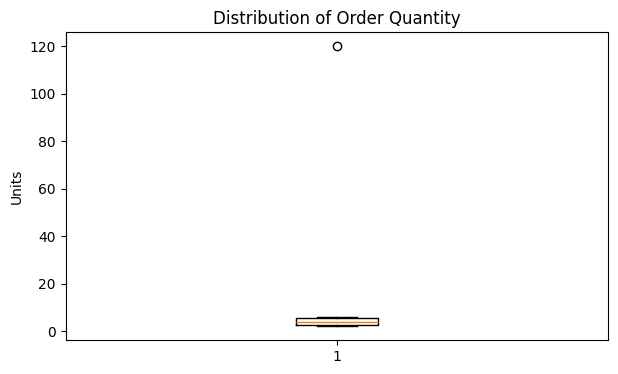

In [ ]:
plt.figure(figsize=(7, 4))
plt.boxplot(raw_orders["Units"].dropna())
plt.ylabel("Units")
plt.title("Distribution of Order Quantity")
plt.show()


### Exercise 3: Build a Clean Copy

Create `orders_clean` and perform these operations:

1. Remove exact duplicate rows.
2. Standardize `Payment_Method` by stripping whitespace and using consistent capitalization.
3. Treat negative `Customer_Age` as missing.
4. Inspect the unusually large `Units` value rather than automatically deleting it.
5. Display the cleaned table.



In [ ]:
# ===================== EXERCISE 3 =====================
orders_clean = raw_orders.copy()

# TODO 1: remove exact duplicates

# TODO 2: clean Payment_Method
# orders_clean["Payment_Method"] = ...

# TODO 3: mark impossible ages as missing

print(orders_clean)


  Order_ID  Units  Customer_Age Payment_Method  Delivery_Days Returned
0     R101    3.0            24           Card              2       No
1     R102    5.0            31           card              3       No
2     R103    NaN            29            UPI              5      Yes
3     R104    4.0            -4           Cash              4       No
4     R105    2.0            46            UPI              2      Yes
5     R105    2.0            46            UPI              2      Yes
6     R106  120.0            37          cash               1       No
7     R107    6.0            28           Card             30       No


## 9. Imputing Categorical Values

Categorical variables require a different kind of imputation.

Suppose a payment method is missing. A simple approach is the most frequent observed category:

**mode imputation**

Another useful option is an explicit category such as `"Unknown"` when missingness itself may carry information.

The choice should reflect the meaning of the feature and the reason values are missing.


In [ ]:
payment_example = pd.Series(["Card", "UPI", "Card", "Cash", np.nan, "Card"])

mode_payment = payment_example.mode()[0]
payment_filled = payment_example.fillna(mode_payment)

print("Mode:", mode_payment)
print("After imputation:")
print(payment_filled.tolist())


Mode: Card
After imputation:
['Card', 'UPI', 'Card', 'Cash', 'Card', 'Card']


## 10. One-Hot Encoding

Many machine-learning algorithms expect numerical inputs.

For **nominal** categories, arbitrary integer labels can create a false order. For example, assigning:

`Cash = 1, Card = 2, UPI = 3`

could incorrectly suggest that UPI is somehow "greater" than Card.

One-hot encoding instead creates one binary feature per category.

Example:

`Payment_Method = UPI`

becomes a vector such as:

`[Card=0, Cash=0, UPI=1]`


In [ ]:
payment_demo = pd.DataFrame({
    "Payment_Method": ["Card", "Cash", "UPI", "Card", "UPI"]
})

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(payment_demo[["Payment_Method"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Payment_Method"])
)

print(encoded_df)


   Payment_Method_Card  Payment_Method_Cash  Payment_Method_UPI
0                  1.0                  0.0                 0.0
1                  0.0                  1.0                 0.0
2                  0.0                  0.0                 1.0
3                  1.0                  0.0                 0.0
4                  0.0                  0.0                 1.0


### Exercise 4: Why Not 1, 2, 3?

Suppose a nominal feature `Browser` contains:

`Chrome`, `Firefox`, `Safari`

Answer:

1. Why can `Chrome=1`, `Firefox=2`, `Safari=3` be misleading?
2. What false notion of distance could a model infer?
3. How would one-hot encoding avoid this issue?

Write a short conceptual answer.


---
# Part B: Normalization, Standardization & Scaling


## 11. Why Does Feature Scaling Matter?

Features can use very different numerical units.

Consider two measurements of a house:
- floor area in square metres,
- distance to the nearest metro station in metres.

A distance calculation could be dominated by the feature with the larger numerical magnitude even when the two variables are both meaningful.

This is why **feature scaling** is often important for methods whose behavior depends on:
- distance,
- magnitude,
- variance,
- or optimization geometry.


In [ ]:
# A simple geometric illustration
difference_area = 12       # square metres
difference_distance = 1500 # metres

raw_distance = np.sqrt(difference_area**2 + difference_distance**2)

print("Raw Euclidean distance:", raw_distance)
print("Contribution from area term:", difference_area**2)
print("Contribution from distance term:", difference_distance**2)


Raw Euclidean distance: 1500.0479992320245
Contribution from area term: 144
Contribution from distance term: 2250000


## 12. Scaling Terminology

### Feature scaling
The general idea of putting numerical features on comparable scales.

### Min-Max normalization
$$
x_{scaled} = \frac{x-x_{min}}{x_{max}-x_{min}}
$$

A common target range is `[0, 1]`.

### Z-score standardization
$$
z = \frac{x-\mu}{\sigma}
$$

The transformed feature has approximately:
- mean = 0
- standard deviation = 1


In [ ]:
v = np.array([6.0, 8.0])

norm = np.linalg.norm(v)
unit_v = v / norm

print("Original vector:", v)
print("L2 norm:", norm)
print("Unit vector:", unit_v)
print("Unit-vector length:", np.linalg.norm(unit_v))


Original vector: [6. 8.]
L2 norm: 10.0
Unit vector: [0.6 0.8]
Unit-vector length: 1.0


## 13. Min-Max Normalization

Min-Max normalization rescales a feature according to its minimum and maximum:

$$
x_{scaled} = \frac{x-x_{min}}{x_{max}-x_{min}}
$$

For a feature whose minimum is `100` and maximum is `300`, the value `150` becomes:

$$
\frac{150-100}{300-100}=0.25
$$

Min-Max scaling preserves the ordering of the original values, but it can be strongly affected by extreme values.


### Exercise 5: Implement Min-Max Scaling Manually

Given:

`temperature = [10, 15, 20, 25, 30]`

1. Compute the minimum and maximum.
2. Apply the Min-Max formula manually using NumPy.
3. Confirm that the minimum maps to `0` and the maximum maps to `1`.
4. Identify the transformed value corresponding to `20`.


In [ ]:
# ===================== EXERCISE 5 =====================
temperature = np.array([10, 15, 20, 25, 30], dtype=float)

# TODO: implement Min-Max scaling manually
temperature_scaled = ...

print("Scaled values:", temperature_scaled)


Scaled values: Ellipsis


## 14. Min-Max Scaling and Outliers

Min-Max normalization uses the feature's minimum and maximum. Therefore, an extreme observation can determine most of the transformed range.

Use the next example to see what happens when a single unusually large observation is introduced.


In [ ]:
values = np.array([10, 11, 12, 13, 80], dtype=float)
scaled_values = (values - values.min()) / (values.max() - values.min())

comparison = pd.DataFrame({
    "Original": values,
    "MinMax": scaled_values
})

comparison


,Original,MinMax
0,10.0,0.000000
1,11.0,0.014286
2,12.0,0.028571
3,13.0,0.042857
4,80.0,1.000000


## 15. Z-Score Standardization

Z-score standardization uses the feature mean and standard deviation:

$$
z = \frac{x-\mu}{\sigma}
$$

Interpretation:
- `z = 0` → value equals the mean,
- `z > 0` → value is above the mean,
- `z < 0` → value is below the mean,
- `z = 2` → value is two standard deviations above the mean.

Unlike Min-Max scaling, Z-score standardization has no fixed upper or lower bound.


In [ ]:
readings = np.array([42, 46, 48, 54, 60], dtype=float)

mu = readings.mean()
sigma = readings.std()

z = (readings - mu) / sigma

print("Mean:", mu)
print("Standard deviation:", sigma)
print("Z-scores:", np.round(z, 3))


Mean: 50.0
Standard deviation: 6.324555320336759
Z-scores: [-1.265 -0.632 -0.316  0.632  1.581]


### Exercise 6: Compare the Two Scalers

Use the following data:

`[4, 5, 7, 8, 16]`

1. Calculate Min-Max normalized values.
2. Calculate Z-score standardized values.
3. Which transformation is constrained to `[0,1]`?
4. Which transformation is centered around zero?
5. Which statistic does each method use?


In [ ]:
# ===================== EXERCISE 6 =====================
x = np.array([4, 5, 7, 8, 16], dtype=float)

# TODO
minmax_x = ...
zscore_x = ...

print("Min-Max:", minmax_x)
print("Z-score:", zscore_x)


Min-Max: Ellipsis
Z-score: Ellipsis


## 16. Data Leakage

A crucial preprocessing mistake is calculating preprocessing parameters using the complete dataset before the train/test split.

For example, computing:

- global mean,
- global standard deviation,
- global minimum,
- global maximum

using both training and test observations allows information from the test set to influence preprocessing.

That is **data leakage**.

### Correct principle

> **Split first. Fit preprocessing on the training set only. Then transform validation/test data using the fitted parameters.**


### Correct Workflow

**Raw data → Split → Fit scaler on training data → Transform train/test → Train model → Evaluate**

The test set must not be used to learn preprocessing parameters.


In [ ]:
# Demonstration of the correct pattern

demo_X = np.array([[10.0], [20.0], [30.0], [40.0], [100.0]])
demo_train = demo_X[:4]
demo_test = demo_X[4:]

scaler = MinMaxScaler()
scaler.fit(demo_train)

print("Training min:", scaler.data_min_)
print("Training max:", scaler.data_max_)

print("Transformed training:", scaler.transform(demo_train).ravel())
print("Transformed test:", scaler.transform(demo_test).ravel())


Training min: [10.]
Training max: [40.]
Transformed training: [0.         0.33333333 0.66666667 1.        ]
Transformed test: [3.]


### Exercise 8: Identify the Leakage

Suppose someone writes:

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
```

Is this safe?

Explain:
1. What information leaked?
2. Why does the ordering violate the lecture's recommended workflow?
3. Rewrite the sequence in the correct order.


---
# Part C: End-to-End Preprocessing Pipeline


## 17. Turning the Retail Data into a Model-Ready Representation

We now combine the preprocessing ideas.

A sensible pipeline is:

1. Remove accidental duplicates.
2. Clean categorical text.
3. Mark impossible numerical values as missing.
4. Impute missing values using a justified strategy.
5. Encode categorical features.
6. Separate target and input features.
7. Split into training and test sets.
8. Fit numerical scaling parameters on the training data only.
9. Transform the training and test features using those fitted parameters.

This is the bridge from raw observations to model-ready data.


In [ ]:
# Demonstration: prepare a clean retail table
orders_ready = raw_orders.drop_duplicates().copy()

orders_ready["Payment_Method"] = (
    orders_ready["Payment_Method"].str.strip().str.title()
)

orders_ready.loc[orders_ready["Customer_Age"] < 0, "Customer_Age"] = np.nan

# For this small teaching example, use median imputation for numeric columns.
for col in ["Units", "Customer_Age", "Delivery_Days"]:
    orders_ready[col] = orders_ready[col].fillna(orders_ready[col].median())

orders_ready


,Order_ID,Units,Customer_Age,Payment_Method,Delivery_Days,Returned
0,R101,3.0,24.0,Card,2,No
1,R102,5.0,31.0,Card,3,No
2,R103,4.5,29.0,Upi,5,Yes
3,R104,4.0,30.0,Cash,4,No
4,R105,2.0,46.0,Upi,2,Yes
6,R106,120.0,37.0,Cash,1,No
7,R107,6.0,28.0,Card,30,No


## 18. Encoding and Scaling the Retail Features

For demonstration, we will one-hot encode the payment method and standardize the numerical columns.



In [ ]:
numeric_cols = ["Units", "Customer_Age", "Delivery_Days"]
categorical_cols = ["Payment_Method"]

X_numeric = orders_ready[numeric_cols]
X_categorical = orders_ready[categorical_cols]

scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_categorical_encoded = encoder.fit_transform(X_categorical)

X_retail_ready = pd.DataFrame(
    np.hstack([X_numeric_scaled, X_categorical_encoded]),
    columns=numeric_cols + list(encoder.get_feature_names_out(categorical_cols))
)

X_retail_ready


,Units,Customer_Age,Delivery_Days,Payment_Method_Card,Payment_Method_Cash,Payment_Method_Upi
0,-0.434763,-1.214141,-0.491716,1.0,0.0,0.0
1,-0.385479,-0.170406,-0.387413,1.0,0.0,0.0
2,-0.397800,-0.468616,-0.178806,0.0,0.0,1.0
3,-0.410121,-0.319511,-0.283109,0.0,1.0,0.0
4,-0.459406,2.066169,-0.491716,0.0,0.0,1.0
5,2.448405,0.724224,-0.596020,0.0,1.0,0.0
6,-0.360836,-0.617721,2.428781,1.0,0.0,0.0


### Exercise 9: Verify the Model-Ready Representation

Inspect `X_retail_ready` and verify:

1. All columns are numerical.
2. Categorical strings are gone.
3. The numerical columns are centered/scaled.
4. No missing values remain.
5. One-hot columns represent the payment categories.

Write a short statement answering:

> **What does the machine-learning algorithm actually see after preprocessing?**


---
# Part D: Multi-Class Classification


## 19. Binary Classification vs. Multi-Class Classification

Binary logistic regression handles two classes:

$$
y \in \{0,1\}
$$

and uses a sigmoid to model one probability.

In multiclass classification there are \(K>2\) mutually exclusive classes. The model must produce a probability for **every class**, while ensuring that the probabilities form one distribution.


## 20. A Multiclass Dataset: Wine Classification
We will use scikit-learn's **Wine dataset**.

The dataset contains chemical measurements of wine samples and three target classes.

This is a useful multiclass setting because:
- there are more than two classes,
- all predictors are numerical,
- the features are measured on different scales,
- and the dataset is small enough to inspect during a lab.

The data will therefore let us connect **preprocessing + scaling + multiclass logistic regression** in one workflow.


In [ ]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Feature matrix shape:", X.shape)
print("Number of classes:", y.nunique())
print("Class counts:")
print(y.value_counts().sort_index())

X.head()


Feature matrix shape: (178, 13)
Number of classes: 3
Class counts:
target
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### Exercise 10: Inspect the Classification Dataset

Before training a model:

1. Check the shape of `X`.
2. Check whether any feature contains missing values.
3. Display the class distribution.
4. Compute the minimum and maximum of at least three features.
5. Explain why feature scaling may be relevant for this dataset.


In [ ]:
# ===================== EXERCISE 10 =====================
print("Missing values:")
print(X.isna().sum())

print("\nClass distribution:")
print(y.value_counts().sort_index())

print("\nSelected feature ranges:")
print(X[["alcohol", "magnesium", "proline"]].agg(["min", "max"]))


Missing values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64

Selected feature ranges:
     alcohol  magnesium  proline
min    11.03       70.0    278.0
max    14.83      162.0   1680.0


## 21. One Logit Per Class

For an input vector \(x\), the multiclass logistic model produces one raw score—or **logit**—for each class:

$$
z_k = w_k^T x + b_k
$$

For \(K\) classes, we obtain:

$$
[z_1, z_2, \ldots, z_K]
$$

These logits are **evidence scores**, not probabilities.

They may:
- be negative,
- be greater than 1,
- and do not need to sum to 1.


## 22. Softmax

Softmax converts the \(K\) logits into a probability distribution:

$$
p_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$

The operation can be understood as:

1. exponentiate each logit,
2. add the exponentials,
3. divide each exponential by the shared total.

The result satisfies:

$$
0 < p_k < 1
$$

and

$$
\sum_{k=1}^{K}p_k = 1.
$$


In [ ]:
def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    shifted = logits - np.max(logits)  # numerical stability
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()

logits = np.array([1.5, 0.2, 2.8, -0.5])
probabilities = softmax(logits)

print("Logits:", logits)
print("Probabilities:", np.round(probabilities, 4))
print("Sum:", probabilities.sum())


Logits: [ 1.5  0.2  2.8 -0.5]
Probabilities: [0.197  0.0537 0.7227 0.0267]
Sum: 1.0


### Exercise 11: Compute Softmax Yourself

For:

`z = [0.5, 2.0, -1.0]`

1. Identify the largest logit.
2. Compute the softmax probabilities using the `softmax()` function.
3. Verify that the probabilities sum to 1.
4. Which class receives the largest probability?
5. Does the softmax ranking agree with the logit ranking?


In [ ]:
# ===================== EXERCISE 11 =====================
z = np.array([0.5, 2.0, -1.0])

# TODO: use the softmax function

#print("Probabilities:", p)
#print("Sum:", p.sum())
#print("Predicted class index:", np.argmax(p))


## 23. Softmax Properties

Three important properties are especially useful:

### 1. Larger logit → larger probability
Softmax preserves the ranking of logits.

### 2. Probabilities are coupled
Increasing one class's probability affects the available probability mass for the other classes.

### 3. Adding the same constant changes nothing

For example:

$$
softmax([1,2,3]) = softmax([11,12,13])
$$

because softmax depends on relative differences between logits.


In [ ]:
a = np.array([1.0, 2.0, 3.0])
b = a + 10

print("softmax(a):", np.round(softmax(a), 6))
print("softmax(b):", np.round(softmax(b), 6))
print("Equal?:", np.allclose(softmax(a), softmax(b)))


softmax(a): [0.090031 0.244728 0.665241]
softmax(b): [0.090031 0.244728 0.665241]
Equal?: True


### Exercise 12: Softmax vs. Independent Sigmoids

Suppose a sample must belong to exactly one of four classes.

Model A outputs four independent sigmoid probabilities.

Model B outputs four softmax probabilities.

Answer:

1. Which model guarantees that the probabilities sum to one?
2. Which formulation naturally represents mutually exclusive classes?
3. Which formulation is more appropriate for the multiclass wine task?
4. When would independent sigmoids be more natural?


## 24. Prediction with Argmax

Once softmax probabilities are available, the predicted class is the class with the largest probability:

$$
\hat{y} = \arg\max_k p_k
$$

Because softmax preserves the ranking of logits, choosing the largest probability is equivalent to choosing the largest logit.


In [ ]:
sample_logits = np.array([-0.7, 1.2, 0.4])
sample_probs = softmax(sample_logits)

print("Logits:", sample_logits)
print("Probabilities:", np.round(sample_probs, 4))
print("Prediction:", np.argmax(sample_probs))


Logits: [-0.7  1.2  0.4]
Probabilities: [0.0935 0.6254 0.281 ]
Prediction: 1


## 25. One-Hot Encoding of the True Class

For exactly one correct class, the target can be represented as a one-hot vector.

For three classes:

| Class index | One-hot target |
|---:|---|
| 0 | `[1, 0, 0]` |
| 1 | `[0, 1, 0]` |
| 2 | `[0, 0, 1]` |

Only one position is 1 because exactly one class is correct.


In [ ]:
class_index = 2
num_classes = 3

one_hot = np.eye(num_classes, dtype=int)[class_index]

print("Class index:", class_index)
print("One-hot label:", one_hot)


Class index: 2
One-hot label: [0 0 1]


## 26. Likelihood and Categorical Cross-Entropy

Let the true one-hot label be \(y\) and predicted probabilities be \(p\).

The categorical likelihood is:

$$
P(y|x)=\prod_{k=1}^{K}p_k^{y_k}
$$

Because only one component of \(y\) is 1, this product selects the probability assigned to the true class.

Taking the negative logarithm gives categorical cross-entropy:

$$
L=-\sum_{k=1}^{K}y_k\log(p_k)
$$

For one observation this reduces to:

$$
L=-\log(p_{correct})
$$

So:
- high probability on the true class → low loss,
- low probability on the true class → high loss.


In [ ]:
true_class = 1
p = np.array([0.15, 0.70, 0.15])

y_one_hot = np.eye(3)[true_class]
likelihood = np.prod(p ** y_one_hot)
loss = -np.sum(y_one_hot * np.log(p))

print("True class:", true_class)
print("One-hot:", y_one_hot)
print("Likelihood:", likelihood)
print("Cross-entropy:", loss)
print("-log(correct probability):", -np.log(p[true_class]))


True class: 1
One-hot: [0. 1. 0.]
Likelihood: 0.7
Cross-entropy: 0.35667494393873245
-log(correct probability): 0.35667494393873245


### Exercise 13: Loss Sensitivity

The true class is class `0`.

Compare:

- Prediction A: `[0.82, 0.10, 0.08]`
- Prediction B: `[0.20, 0.30, 0.50]`

1. Which prediction has lower cross-entropy?
2. Compute both losses manually with `-log(p_correct)`.
3. Which model assigned more probability to the true class?
4. Why does the loss become large when the correct-class probability becomes small?


In [ ]:
# ===================== EXERCISE 13 =====================
p_A = np.array([0.82, 0.10, 0.08])
p_B = np.array([0.20, 0.30, 0.50])

# True class is 0
# TODO
loss_A = ...
loss_B = ...

print("Loss A:", loss_A)
print("Loss B:", loss_B)


Loss A: Ellipsis
Loss B: Ellipsis


## 27. Cost Over a Dataset

For \(m\) observations and \(K\) classes:

$$
J(W,b)=-\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K}y_{ik}\log(p_{ik})
$$

The dataset cost is therefore the average categorical cross-entropy over the training examples.

This gives the same conceptual story emphasized in the lecture:

**maximum likelihood → maximize log-likelihood → minimize negative log-likelihood → cross-entropy**


In [ ]:
# Small numerical verification
prob_matrix = np.array([
    [0.70, 0.20, 0.10],
    [0.10, 0.80, 0.10],
    [0.20, 0.30, 0.50]
])

true_indices = np.array([0, 1, 2])
Y = np.eye(3)[true_indices]

manual_cost = -np.mean(np.sum(Y * np.log(prob_matrix), axis=1))

print("Manual categorical cross-entropy:", manual_cost)


Manual categorical cross-entropy: 0.4243218919376292


## 28. Training vs. Inference

| Training | Inference |
|---|---|
| True labels are available | True labels are unavailable |
| Compute loss | No training loss is required |
| Update model parameters | Use learned parameters |
| Goal: reduce the training objective | Goal: predict new samples |

Training **learns parameters**. Inference **uses learned parameters to make predictions**.


---
# Part E: Leakage-Safe Multiclass Logistic Regression


## 29. Split First, Then Scale the Wine Data

We now apply the lecture's preprocessing rule to a real multiclass dataset.

The order matters:

1. separate features and labels,
2. split into train and test sets,
3. fit the scaler on **training features only**,
4. transform both training and test features,
5. train the classifier,
6. evaluate on the test set.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Training mean (first 3 features):", np.round(X_train_scaled.mean(axis=0)[:3], 4))
print("Training std  (first 3 features):", np.round(X_train_scaled.std(axis=0)[:3], 4))


Training shape: (133, 13)
Test shape: (45, 13)
Training mean (first 3 features): [0. 0. 0.]
Training std  (first 3 features): [1. 1. 1.]


### Exercise 14: Check for Leakage

Answer:

1. Which data was used in `scaler.fit(...)`?
2. Was `X_test` used to estimate the mean or standard deviation?
3. Why is `scaler.transform(X_test)` allowed even though the test data must remain unseen?
4. What would happen if we called `fit_transform` separately on `X_test`?


## 30. Train Multiclass Logistic Regression

We now train a logistic regression classifier on the standardized Wine features.

With three target classes, the model must distinguish among all three classes and produce a probability for each class.

We will inspect both:
- the predicted class,
- and the full probability vector.


In [ ]:
clf = LogisticRegression(max_iter=2000)

clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)

print("Predicted classes:", y_pred[:10])
print("\nProbability matrix shape:", y_prob.shape)
print("\nFirst 5 probability vectors:")
print(np.round(y_prob[:5], 4))


Predicted classes: [0 1 0 0 1 0 0 1 1 2]

Probability matrix shape: (45, 3)

First 5 probability vectors:
[[9.259e-01 7.250e-02 1.600e-03]
 [3.800e-03 9.961e-01 1.000e-04]
 [9.993e-01 2.000e-04 5.000e-04]
 [9.903e-01 9.400e-03 3.000e-04]
 [3.000e-04 9.994e-01 3.000e-04]]


## 31. Relating the Library Output to Softmax

For multiclass logistic regression, the classifier produces one score per class and converts those scores into class probabilities.

We can verify the most important behavior from the lecture directly:

- each probability lies between 0 and 1,
- probabilities for a sample sum to 1,
- the class with the largest probability is the predicted class.


In [ ]:
row = 0

print("Probability vector:", np.round(y_prob[row], 5))
print("Sum:", y_prob[row].sum())
print("Predicted class from probabilities:", np.argmax(y_prob[row]))
print("Model prediction:", y_pred[row])


Probability vector: [0.92591 0.07245 0.00163]
Sum: 1.0
Predicted class from probabilities: 0
Model prediction: 0


### Exercise 15: Inspect Three Predictions

Select any three test samples and for each one report:

1. the predicted class,
2. the probability vector,
3. the largest probability,
4. whether the prediction is correct.

Then comment on whether the model is confident or uncertain for each sample.


In [ ]:
# ===================== EXERCISE 15 =====================
# TODO: choose three indices from the test set



## 32. Accuracy and Confusion Matrix

Accuracy is the fraction of test observations classified correctly:

$$
Accuracy=\frac{\text{correct predictions}}{\text{total predictions}}
$$

A confusion matrix gives more detail.

For multiclass classification:
- rows = true classes,
- columns = predicted classes.

The diagonal contains correct predictions. Off-diagonal entries show which classes are being confused.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", accuracy)
print("\nConfusion matrix:")
print(cm)


Test accuracy: 1.0

Confusion matrix:
[[15  0  0]
 [ 0 18  0]
 [ 0  0 12]]


## 33. Visualize the Confusion Matrix

A simple heatmap-style display makes the class-wise errors easier to inspect.


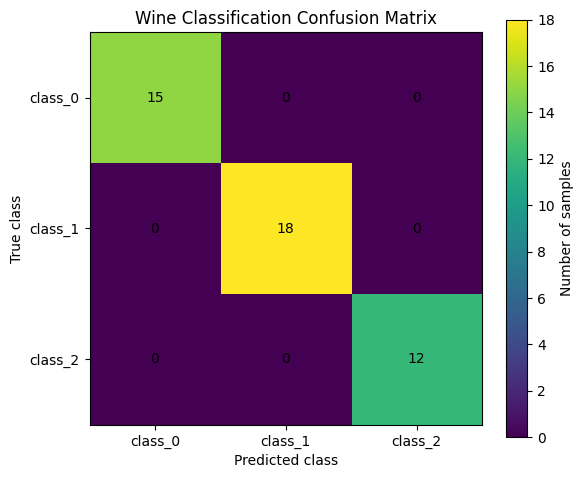

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Wine Classification Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(len(wine.target_names)), wine.target_names)
plt.yticks(range(len(wine.target_names)), wine.target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(label="Number of samples")
plt.tight_layout()
plt.show()


## 34. Cross-Entropy on the Test Set

Accuracy only checks whether the most likely class is correct.

Cross-entropy also considers **how much probability** the model assigned to the true class.

We can calculate the average categorical cross-entropy using `log_loss`.


In [ ]:
test_ce = log_loss(y_test, y_prob)

print("Test categorical cross-entropy:", test_ce)


Test categorical cross-entropy: 0.06707141252563355


### Exercise 16: Accuracy vs. Probability Quality

Consider two predictions for a sample whose true class is class `1`:

- Model A: `[0.20, 0.51, 0.29]`
- Model B: `[0.02, 0.95, 0.03]`

1. Are both predictions correct?
2. Which has lower cross-entropy?
3. Which is more confident?
4. Why can cross-entropy reveal information that accuracy cannot?


## 35. Classification Report

Accuracy is useful, but class-wise precision and recall can reveal asymmetric errors.

For example, a model might perform very well overall but confuse one particular class more often than the others.

We therefore inspect a standard classification report as an additional diagnostic.


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names,
    digits=3
))


              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        15
     class_1      1.000     1.000     1.000        18
     class_2      1.000     1.000     1.000        12

    accuracy                          1.000        45
   macro avg      1.000     1.000     1.000        45
weighted avg      1.000     1.000     1.000        45



---
# Part F: Final Integrated Practical


## Exercise 17: Build the Complete Pipeline Yourself

Use the Wine dataset to rebuild the complete workflow without copying the earlier solution.

Your pipeline should contain:

1. Load the feature matrix and target.
2. Inspect shape, class counts, and missing values.
3. Split into training and test sets with stratification.
4. Choose either **Min-Max normalization** or **Z-score standardization**.
5. Fit the scaler only on the training features.
6. Transform both train and test features.
7. Train multiclass logistic regression.
8. Generate class predictions and probability vectors.
9. Compute accuracy.
10. Compute categorical cross-entropy.
11. Display the confusion matrix.
12. Inspect at least three probability vectors.
13. State one reason why your chosen scaling method is appropriate.
14. Explain how you avoided data leakage.


In [ ]:
# ===================== EXERCISE 17 =====================

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix

data = load_wine()
X_final = data.data
y_final = data.target

# TODO 1: inspect the data

# TODO 2: split the data

# TODO 3: choose and fit your scaler on training data only

# TODO 4: train the multiclass classifier

# TODO 5: predict classes and probabilities

# TODO 6: evaluate

# TODO 7: inspect three probability vectors


## Final Interpretation Questions

Answer these after completing Exercise 17.

### Preprocessing
1. Why should preprocessing parameters be learned from training data only?
2. What is the difference between a missing value and a zero?
3. Why should an outlier not automatically be deleted?
4. Why is one-hot encoding appropriate for a nominal category?

### Scaling
5. State the formulas for Min-Max normalization and Z-score standardization.
6. Why can Min-Max scaling be sensitive to extreme values?
7. What is the difference between feature-wise Min-Max scaling and unit-vector normalization?
8. Name two algorithms for which scaling is often important and explain why.

### Multi-class classification
9. What is the role of a logit?
10. Why does softmax produce a probability distribution?
11. Why is softmax more appropriate than independent sigmoids for mutually exclusive classes?
12. Why does `argmax` select the predicted class?

### Loss
13. Why does categorical cross-entropy depend strongly on the probability assigned to the true class?
14. Explain the relationship between likelihood, log-likelihood, negative log-likelihood, and cross-entropy.

### Evaluation
15. Why is a confusion matrix useful in addition to accuracy?
16. How can two models have the same accuracy but different cross-entropy?


### Answers

